## Notes by Andrea

### Download data

In [98]:
import pandas as pd
import numpy as np
import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pooch import retrieve

# Read data, put in pandas dataframe
url = "https://osf.io/download/qsb3f"
path = retrieve(url=url, known_hash=None)
data = pd.read_csv(path, encoding="latin1", sep = ';')
print(data.head())

               Source        AuthorName  Experiment  Year        Group  \
0  Goldstein.2008.Ex1  Goldstein et al.           1  2008      Control   
1  Goldstein.2008.Ex1  Goldstein et al.           1  2008  Social Norm   
2  Goldstein.2008.Ex1  Goldstein et al.           1  2008      Control   
3  Goldstein.2008.Ex1  Goldstein et al.           1  2008  Social Norm   
4  Goldstein.2008.Ex2  Goldstein et al.           2  2008      Control   

  Towel.Reuse  Count  
0         Yes     74  
1         Yes     98  
2          No    137  
3          No    124  
4         Yes    103  


### Data wrangling
Copied from exercise instructions

In [99]:
count = data.iloc[:, -1] # get the last column with numbers or yes/no

# count has the number of yes and no for control and social norm groups
control_yes = count[::4].to_numpy() # every 4th starting from 0 - control group + yes
control_no = count[2::4].to_numpy() # every 4th starting from 2 - control group + no
control_total = np.array([y + n for y, n in zip(control_yes, control_no)])

social_yes = count[1::4].to_numpy() # every 4th starting from 1 - social norm group + yes
social_no = count[3::4].to_numpy() # every 4th starting from 3 - social norm group + no
social_total = np.array([y + n for y, n in zip(social_yes, social_no)])

study = np.arange(1,len(control_yes)+1) # 7 different studies
control_data = pd.DataFrame({"reuse": control_yes, "total": control_total, "group": "control", "study": study})
social_data = pd.DataFrame({ "reuse": social_yes, "total": social_total, "group": "social", "study": study})

combined_data = pd.concat([control_data, social_data], ignore_index=True)

# Convert data types - important for bambi that they are correctly set. an give errors otherwise
combined_data['reuse'] = combined_data['reuse'].astype(int)
combined_data['total'] = combined_data['total'].astype(int)
combined_data['group'] = combined_data['group'].astype('category')
combined_data['study'] = combined_data['study'].astype('category')

print(combined_data.head())



   reuse  total    group study
0     74    211  control     1
1    103    277  control     2
2     77    135  control     3
3     82    187  control     4
4     21     25  control     5


### Theory

The response variable follows a binomial distrubution

Use a model with a group specific intercept for each study (intercept is a random effect). Use a shared slope (fixed effect). This means that the effect is overall the same (difference between no social norm and with social norm) but that the studies may differ in other ways - like choice of hotel or area, or time of the study.

Model to use (written using two different notations): 
$$
\begin{aligned}
y_{ij} &= \beta_0 + u_{j} + \beta_1 x_{ij} + \epsilon_{ij} \\
Y_{ij} |x &\sim N(\beta_0 + u_{j} + \beta_1 x_{ij}, \sigma) 
\end{aligned}
$$
where $u_{j}$ represents the random effect for each study, $\beta_0 + u_{j}$ represents the intercept for each study and $\beta_1$ represents the slope. 
$$
u_{j} \sim N(0, \tau)
$$
The parameters (priors?) are: $\beta_0, \beta_1, \sigma$ and $\tau$. They are specified using the following distributions, with hyper parameters (also called hyper priors) $\mu_{\beta_0}$, $\mu_{\beta_1}$, $a_\sigma$, $b_\sigma$ etc.
$$
\begin{aligned}
\beta_0 &\sim N(\mu_{\beta_0}, \sigma_{\beta_0}) \\
\beta_1 &\sim N(\mu_{\beta_1}, \sigma_{\beta_1}) \\
\sigma &\sim \Gamma(a_\sigma, b_\sigma) \\
\tau &\sim \Gamma(a_\tau, b_\tau) 
\end{aligned}
$$
There are built in hyper parameters when using bambi. Do not change these.

### Model speficication and priors

In [100]:
# Model with random interecept for each study and no group (null hypothesis)
m1 = bmb.Model("p(reuse, total) ~ 1 + (1|study)", combined_data, family="binomial") 
print(m1)
print("")

# Model with random interecept for each study and group (control/social) as intercept (kind of)
m2 = bmb.Model("p(reuse, total) ~ 1 + group + (1|study)", combined_data, family="binomial") 
print(m2)

       Formula: p(reuse, total) ~ 1 + (1|study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))

       Formula: p(reuse, total) ~ 1 + group + (1|study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5495))


### Fit the model

In [ ]:
idata1 = m1.fit() 
idata2 = m2.fit() # Initial model, nothing changed by us

#idata2 = m2.fit(draws = 1000, tune=1000, target_accept=1, seed = 42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, 1|study_sigma, 1|study_offset]


/Users/andrearaaschou/courses/BERN02/group_project/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/andrearaaschou/courses/BERN02/group_project/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


In [102]:
# There is a large numer of divergences (28) - which indicates a problem with the underlying model (according to bambi website)

# Look at the prior predictive distribution - not sure how to do this
idata_prior = m2.prior_predictive()
prior = az.extract(idata_prior, group="prior")["p"]
print(idata_prior)

Sampling: [1|study_offset, 1|study_sigma, Intercept, group, p(reuse, total)]


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:            (chain: 1, draw: 500, group_dim: 1,
│                               study__factor_dim: 7, __obs__: 14)
│       Coordinates:
│         * chain              (chain) int64 8B 0
│         * draw               (draw) int64 4kB 0 1 2 3 4 5 ... 494 495 496 497 498 499
│         * group_dim          (group_dim) <U6 24B 'social'
│         * study__factor_dim  (study__factor_dim) <U1 28B '1' '2' '3' '4' '5' '6' '7'
│         * __obs__            (__obs__) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
│       Data variables:
│           group              (chain, draw, group_dim) float64 4kB 1.46 ... -0.1561
│           1|study            (chain, draw, study__factor_dim) float64 28kB -0.1973 ...
│           p                  (chain, draw, __obs__) float64 56kB 0.06891 ... 0.5839
│           Intercept          (chain, draw) float64 4kB -1.676 -0.9731 ... 0.8175 2.702
│           1|study_sigma      (chain, draw) float64 4kB 0

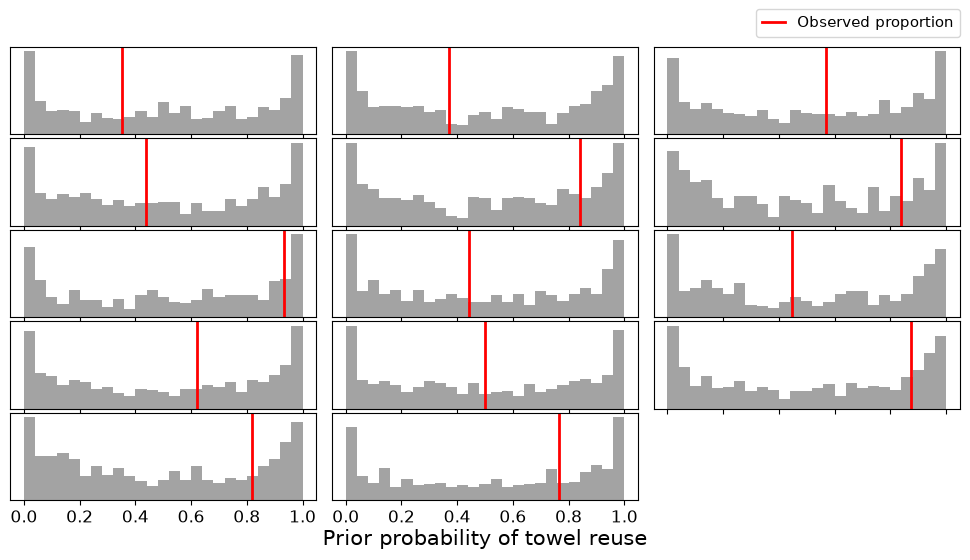

In [ ]:
def plot_prior_predictive(df, prior):
    total = df["total"].values
    reuse = df["reuse"].values
    fig, axes = plt.subplots(5, 3, figsize=(10, 6), sharex="col")

    for idx, ax in enumerate(axes.ravel()):
        # Stop after the 14 observations
        if idx >= len(df):
            ax.axis("off")
            continue

        pps = prior.sel({"__obs__": idx})
        observed_proportion = reuse[idx] / total[idx]
        ax.hist(pps, bins=25, color="#a3a3a3")
        ax.axvline(observed_proportion, color="red", lw=2)
        ax.set_yticks([])
        ax.tick_params(labelsize=12)

    fig.subplots_adjust(
        left=0.025,
        right=0.975,
        hspace=0.05,
        wspace=0.05,
        bottom=0.125)

    fig.legend(
        handles=[
            Line2D(
                [0], [0],
                label="Observed proportion",
                color="red",
                linewidth=2)],
        handlelength=1.5,
        handletextpad=0.8,
        borderaxespad=0,
        frameon=True,
        fontsize=11,
        bbox_to_anchor=(0.975, 0.92),
        loc="right")

    fig.text(
        0.5,
        0.05,
        "Prior probability of towel reuse",
        fontsize=15,
        ha="center",
        va="baseline")

plot_prior_predictive(combined_data, prior)

These plots tells us that the prior are too wide (bambi documentation). In the following code, try to tighten the priors.

In [112]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1), # Changed sigma from 1.5 to 0.5
    "1|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=2)) # Changed sigma from 1.5 to 0.5
}
m3 = bmb.Model("p(reuse, total) ~ 1 + group + (1|study)", combined_data, family="binomial", priors=priors)
m3

idata3 = m3.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/andrearaaschou/courses/BERN02/group_project/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


This is much better (I think), 16 divergences instead of 28 divergences.

Sampling: [1|study_offset, 1|study_sigma, Intercept, group, p(reuse, total)]


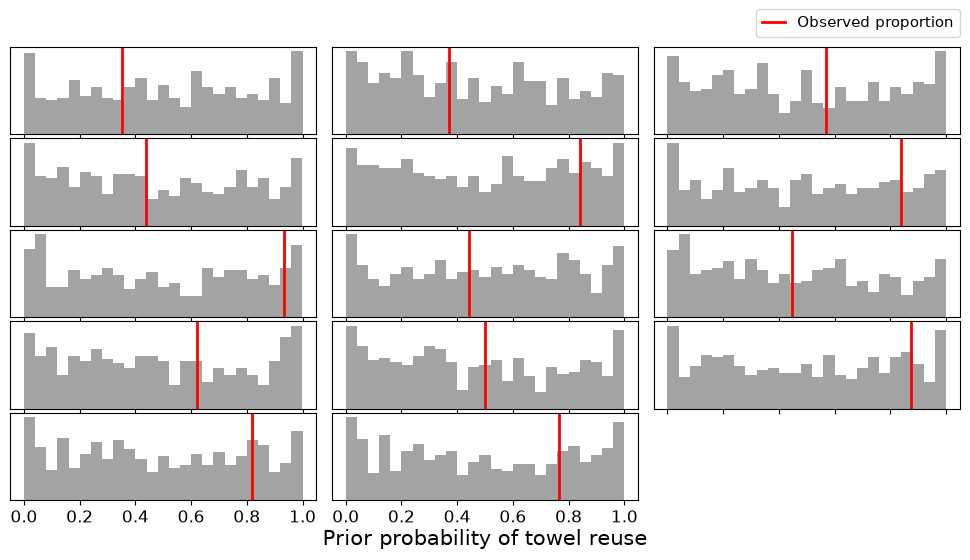

In [113]:
m3.build()
idata_prior = m3.prior_predictive()
prior = az.extract(idata_prior, group="prior")["p"]
plot_prior_predictive(combined_data, prior)

Slightly better but still not what we want?

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/andrearaaschou/courses/BERN02/group_project/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
There were 22 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [1|study_offset, 1|study_sigma, Intercept, group, p(reuse, total)]


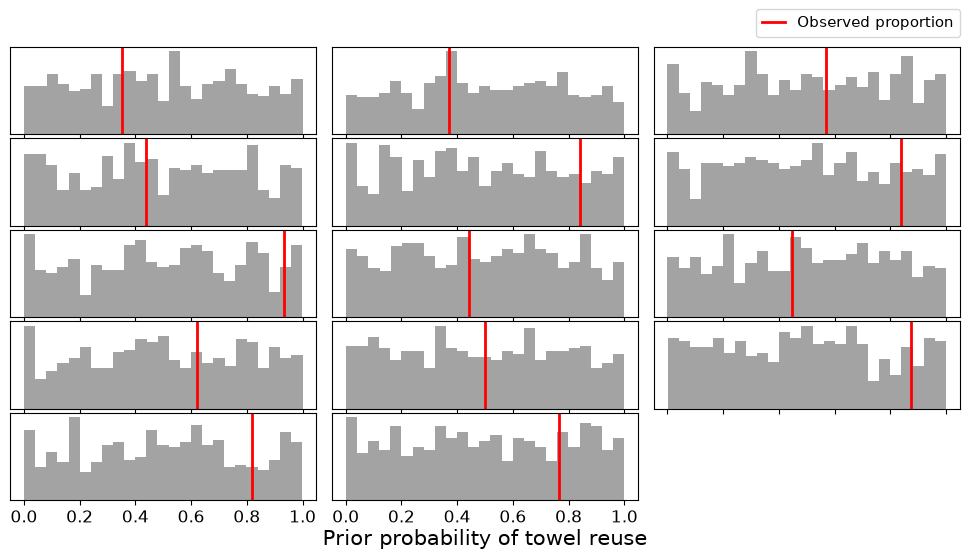

In [117]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1), 
    "1|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=1.5)) # Changed sigma from 2 to 1.5
}
m3 = bmb.Model("p(reuse, total) ~ 1 + group + (1|study)", combined_data, family="binomial", priors=priors)
m3

idata3 = m3.fit()

m3.build()
idata_prior = m3.prior_predictive()
prior = az.extract(idata_prior, group="prior")["p"]
plot_prior_predictive(combined_data, prior)

In [122]:
idata3 = m3.fit(target_accept = 0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/andrearaaschou/courses/BERN02/group_project/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


ValueError: Keyword arguments ['kind'] have been passed as **kwargs but have no active aesthetic mapped to them. Keyword arguments must define values to use in their respective aesthetic mapping.

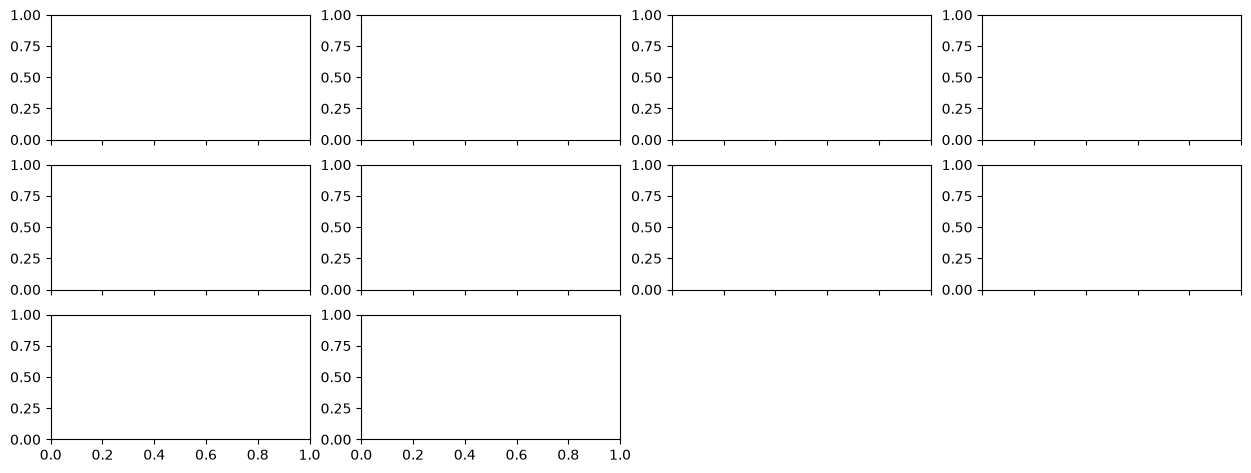

In [ ]:
var_names = ["Intercept", "group", "1|study", "1|study_sigma"]
az.plot_trace(idata3, var_names=var_names, kind=("trace", "rank_bars"))
plt.gcf().set_size_inches(18, 8)
# Find all axes and make their y-axis limits the same
all_axes = plt.gcf().axes

y_limits = [ax.get_ylim() for ax in all_axes]
y_min = min(y[0] for y in y_limits)
y_max = max(y[1] for y in y_limits)

for ax in all_axes:
    ax.set_ylim(y_min, y_max)
plt.tight_layout()

print(idata3.posterior.data_vars)
